This nootebook is intenden only for pictures.
I take the best dataset from the regressions and see the age distribution 
- originally
- after the test and train divission
- after the SMOTE

In [2]:
import os
import feature_selection as fs
import pandas as pd
import model as m
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import feature_selection as fs
import model as m

2024-05-27 11:58:52.054038: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-27 11:58:52.055804: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-27 11:58:52.080390: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-27 11:58:52.080414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-27 11:58:52.080982: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
all_rna_seq_data = pd.read_csv("/home/karen/Documents/phd/Data/Batch_corrected/RNAs_z_Combat_2.csv")
all_rna_seq_data["Age"].describe()

count    270.000000
mean      53.384444
std       22.386252
min       18.000000
25%       27.500000
50%       65.500000
75%       71.000000
max       92.000000
Name: Age, dtype: float64

In [4]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
#age_ranges_list=[18, 25, 35, 45, 55, 65, 75, 85, 95, 100]
standar_age_range=[18,35,65,100]

# Original Data

<Figure size 1000x600 with 0 Axes>

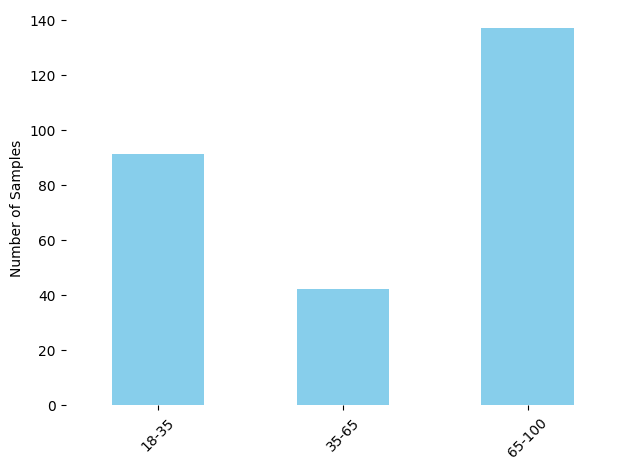

In [5]:
standar_age_ranges = fs.get_age_distribution(all_rna_seq_data["Age"], age_ranges=standar_age_range)
x_labels = [age['label'] for age in standar_age_ranges]

plt.figure(figsize=(10, 6))
pd.DataFrame(standar_age_ranges).plot(kind='bar', xticks=range(len(standar_age_ranges)), color='skyblue', legend=False)
#plt.title('Distribution of Age Groups Training Set')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(standar_age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.show()

<Figure size 1000x600 with 0 Axes>

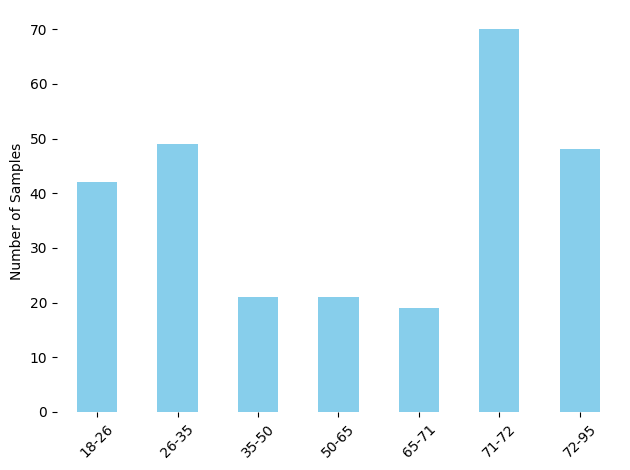

In [6]:
age_ranges = fs.get_age_distribution(all_rna_seq_data["Age"], age_ranges=age_ranges_list)
x_labels = [age['label'] for age in age_ranges]

plt.figure(figsize=(10, 6))
pd.DataFrame(age_ranges).plot(kind='bar', xticks=range(len(age_ranges)), color='skyblue', legend=False)
#plt.title('Distribution of Age Groups Training Set')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.show()

In [6]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = m.divide_test_train_dataset(all_rna_seq_data, test_size=0.4)


## Training

In [7]:
train_age_ranges = fs.get_age_distribution(seq_y_train, age_ranges=age_ranges_list)
train_age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 29},
 {'label': '26-35', 'range': (26, 35), 'count': 26},
 {'label': '35-50', 'range': (35, 50), 'count': 13},
 {'label': '50-65', 'range': (50, 65), 'count': 12},
 {'label': '65-71', 'range': (65, 71), 'count': 10},
 {'label': '71-72', 'range': (71, 72), 'count': 45},
 {'label': '72-95', 'range': (72, 95), 'count': 27}]

In [8]:
test_age_ranges = fs.get_age_distribution(seq_y_test, age_ranges=age_ranges_list)
test_age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

<Figure size 1000x600 with 0 Axes>

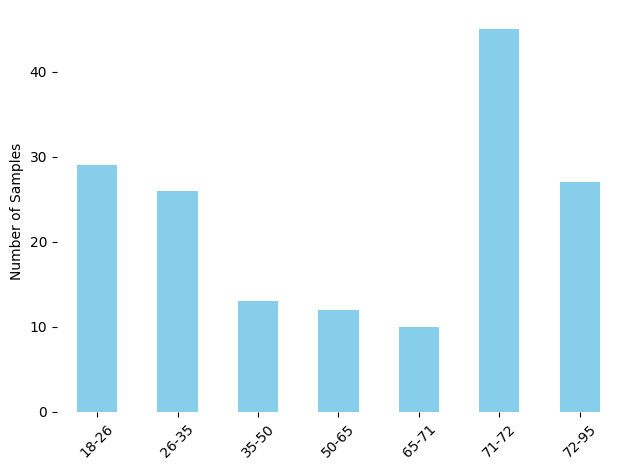

In [9]:
x_labels = [age['label'] for age in train_age_ranges]

plt.figure(figsize=(10, 6))
pd.DataFrame(train_age_ranges).plot(kind='bar', xticks=range(len(train_age_ranges)), color='skyblue', legend=False)
#plt.title('Distribution of Age Groups Training Set')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(train_age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.show()

In [10]:
training_df = pd.concat([seq_X_train,  seq_z_train], axis=1)
training_df.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Experiment,Sample
52,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,71.0,GSE157585,SRR12604093
147,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,77.0,GSE167186,SRR13758996
254,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,58.0,GSE129643,SRR8882184
51,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71.0,GSE157585,SRR12604092
6,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,42.0,GSE164471,SRR13388738


## Testing

<Figure size 1000x600 with 0 Axes>

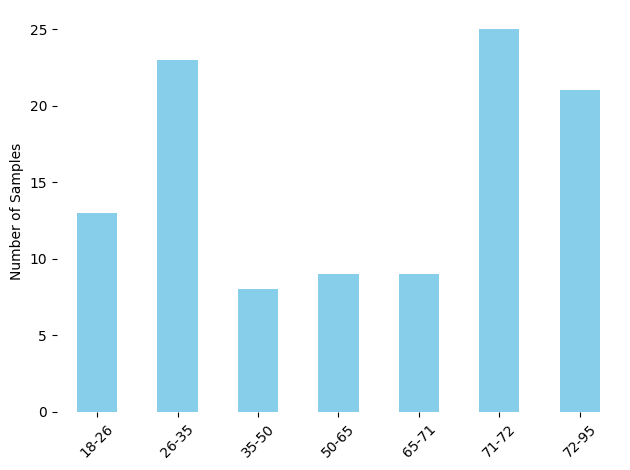

In [11]:
x_labels = [age['label'] for age in test_age_ranges]

plt.figure(figsize=(10, 6))
pd.DataFrame(test_age_ranges).plot(kind='bar', xticks=range(len(test_age_ranges)), color='skyblue', legend=False)
#plt.title('Distribution of Age Groups Training Set')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(test_age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.show()

In [12]:
test_df = pd.concat([seq_X_test,  seq_z_test], axis=1)
test_df.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Experiment,Sample
125,-0.022233,-0.024446,-0.006216,-0.024515,-0.023171,-0.023202,-0.019452,-0.021846,-0.022867,-0.023905,...,-0.024511,-0.024499,-0.023623,-0.024472,-0.024526,-0.023199,-0.024432,24.0,GSE157585,SRR12604218
174,-0.023307,-0.025360,-0.006206,-0.022286,-0.022653,-0.024454,-0.018532,-0.020077,-0.018804,-0.020995,...,-0.025282,-0.025088,-0.024710,-0.025252,-0.025311,-0.024447,-0.025087,18.0,GSE167186,SRR13759023
176,-0.027950,-0.030171,-0.006227,-0.026315,-0.025683,-0.028757,-0.020073,-0.022860,-0.020748,-0.024276,...,-0.029983,-0.029799,-0.029041,-0.029934,-0.029985,-0.022886,-0.029776,23.0,GSE167186,SRR13759025
232,-0.024681,-0.028953,-0.002464,-0.027633,-0.027815,-0.027149,-0.019945,-0.025554,-0.020408,-0.027101,...,-0.028779,-0.028634,-0.026764,-0.028774,-0.028772,-0.027571,-0.028812,26.4,GSE60590,SRR1555206
100,-0.021846,-0.026700,0.003155,-0.022868,-0.023732,-0.026121,-0.013602,-0.018935,-0.015076,-0.019944,...,-0.026766,-0.026488,-0.026991,-0.026722,-0.026784,-0.025465,-0.026577,71.0,GSE157585,SRR12604184


# Using SMOTE

In [13]:
dataset = pd.DataFrame(seq_X_train)
dataset["Age"]=seq_y_train
dataset["Age"] = all_rna_seq_data['Age'].apply(lambda x: fs.assign_age_group(x, train_age_ranges))
not_enough= dataset[dataset["Age"] == "85-95"]
dataset = dataset[dataset["Age"] != "85-95"]
result = fs.get_feature_SMOTE(dataset, is_categorical=True)
#split the "Age" from result by "-" and replace it with the median of those two values

result

Class distribution before SMOTE: Counter({'71-72': 45, '18-26': 29, '72-95': 27, '26-35': 26, '35-50': 13, '50-65': 12, '65-71': 10})
Class distribution after SMOTE: Counter({'71-72': 45, '72-95': 45, '50-65': 45, '35-50': 45, '18-26': 45, '26-35': 45, '65-71': 45})


(     ENSG00000000003.14  ENSG00000000005.5  ENSG00000000419.12  \
 0             -0.027742          -0.032481            0.000939   
 1             -0.018289          -0.024834           -0.002716   
 2             -0.023552          -0.027343           -0.007636   
 3             -0.029005          -0.033401            0.000583   
 4             -0.025443          -0.030270           -0.001806   
 ..                  ...                ...                 ...   
 310           -0.027250          -0.028926           -0.005443   
 311           -0.018330          -0.024945           -0.002786   
 312           -0.020994          -0.027577           -0.003011   
 313           -0.020195          -0.021864           -0.001294   
 314           -0.017896          -0.025496           -0.002146   
 
      ENSG00000000457.13  ENSG00000000460.16  ENSG00000000938.12  \
 0             -0.029697           -0.029711           -0.031883   
 1             -0.023411           -0.023441           -0.

In [14]:
dataset["Age"].value_counts()

Age
71-72    45
18-26    29
72-95    27
26-35    26
35-50    13
50-65    12
65-71    10
Name: count, dtype: int64

In [15]:
age_group = result[1]
data = result[0]
data["Age"] = age_group
data = pd.concat([data, not_enough], axis=0)
data


/tmp/ipykernel_8009/398878235.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["Age"] = age_group


,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027742,-0.032481,0.000939,-0.029697,-0.029711,-0.031883,-0.022563,-0.028709,-0.023524,-0.027502,...,-0.032549,-0.032346,-0.032538,-0.032025,-0.031420,-0.032510,-0.032550,-0.029729,-0.032295,71-72
1,-0.018289,-0.024834,-0.002716,-0.023411,-0.023441,-0.024564,-0.019551,-0.022235,-0.020411,-0.022674,...,-0.024891,-0.024734,-0.024860,-0.024787,-0.024783,-0.024865,-0.024898,-0.027481,-0.024701,72-95
2,-0.023552,-0.027343,-0.007636,-0.025816,-0.025592,-0.026353,-0.021507,-0.020810,-0.022853,-0.023725,...,-0.027358,-0.027431,-0.027354,-0.027349,-0.026726,-0.027418,-0.027347,-0.025376,-0.026991,50-65
3,-0.029005,-0.033401,0.000583,-0.028778,-0.029956,-0.033116,-0.027197,-0.028614,-0.024847,-0.028604,...,-0.033467,-0.033467,-0.033456,-0.033327,-0.031928,-0.033431,-0.033467,-0.030221,-0.033333,71-72
4,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,-0.024588,...,-0.030232,-0.030294,-0.030216,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,35-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,-0.027250,-0.028926,-0.005443,-0.026098,-0.027032,-0.029193,-0.021598,-0.025583,-0.019934,-0.023664,...,-0.028889,-0.029563,-0.028922,-0.029051,-0.027774,-0.028728,-0.028883,-0.027479,-0.028452,72-95
311,-0.018330,-0.024945,-0.002786,-0.023485,-0.023305,-0.024651,-0.019638,-0.022098,-0.020432,-0.022761,...,-0.025008,-0.024834,-0.024973,-0.024888,-0.024889,-0.024971,-0.025015,-0.027523,-0.024816,72-95
312,-0.020994,-0.027577,-0.003011,-0.025598,-0.025785,-0.027018,-0.018877,-0.023724,-0.020839,-0.024546,...,-0.027560,-0.027422,-0.027541,-0.027474,-0.025978,-0.027535,-0.027563,-0.025274,-0.027375,72-95
313,-0.020195,-0.021864,-0.001294,-0.021043,-0.020226,-0.021907,-0.017859,-0.020533,-0.019019,-0.020292,...,-0.022000,-0.021823,-0.021958,-0.021879,-0.022109,-0.021975,-0.022012,-0.018139,-0.021807,72-95


In [16]:
smote_age_ranges = data["Age"].value_counts()
smote_age_ranges

Age
71-72    45
72-95    45
50-65    45
35-50    45
18-26    45
26-35    45
65-71    45
Name: count, dtype: int64

<Figure size 1000x600 with 0 Axes>

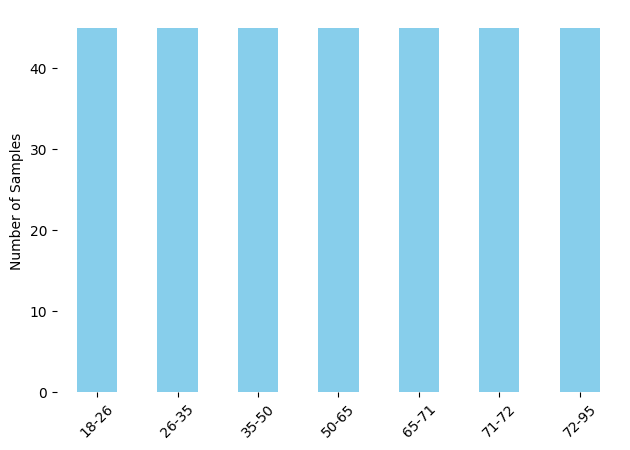

In [17]:
plt.figure(figsize=(10, 6))
pd.DataFrame(smote_age_ranges).plot(kind='bar', xticks=range(len(smote_age_ranges)), color='skyblue', legend=False)
#plt.title('Distribution of Age Groups')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(x_labels)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.xlabel('')
plt.show()

<Figure size 1000x600 with 0 Axes>

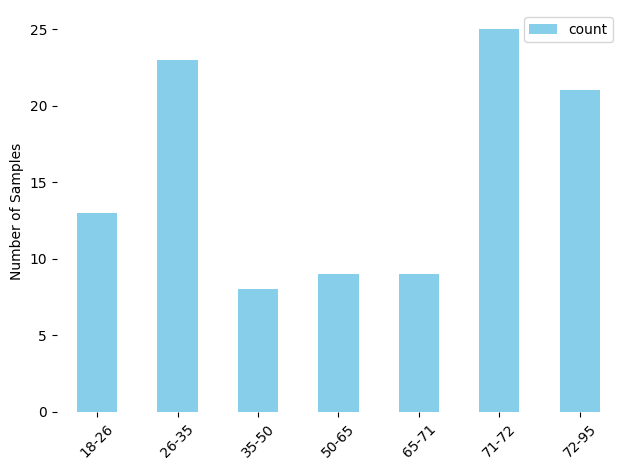

In [18]:
x_labels = [age['label'] for age in test_age_ranges]

plt.figure(figsize=(10, 6))
pd.DataFrame(test_age_ranges).plot(kind='bar', xticks=range(len(test_age_ranges)), color='skyblue')
#plt.title('Distribution of Age Groups Training Set')
#plt.xlabel('Age Group')
plt.ylabel('Number of Samples')
plt.xticks(range(len(test_age_ranges)), x_labels, rotation=45)  # Setting x-tick labels
plt.tight_layout()
plt.box(False)

plt.show()

In [19]:
if print_flag:
    data.to_csv(f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_SMOTE_{len(age_ranges_list)}_b.csv", index=False)
    training_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_train.csv", index=False)
    test_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_2_test.csv", index=False)



In [1]:
print_flag=True
#THis in intentionall like this to avoid saving by accident on the testing